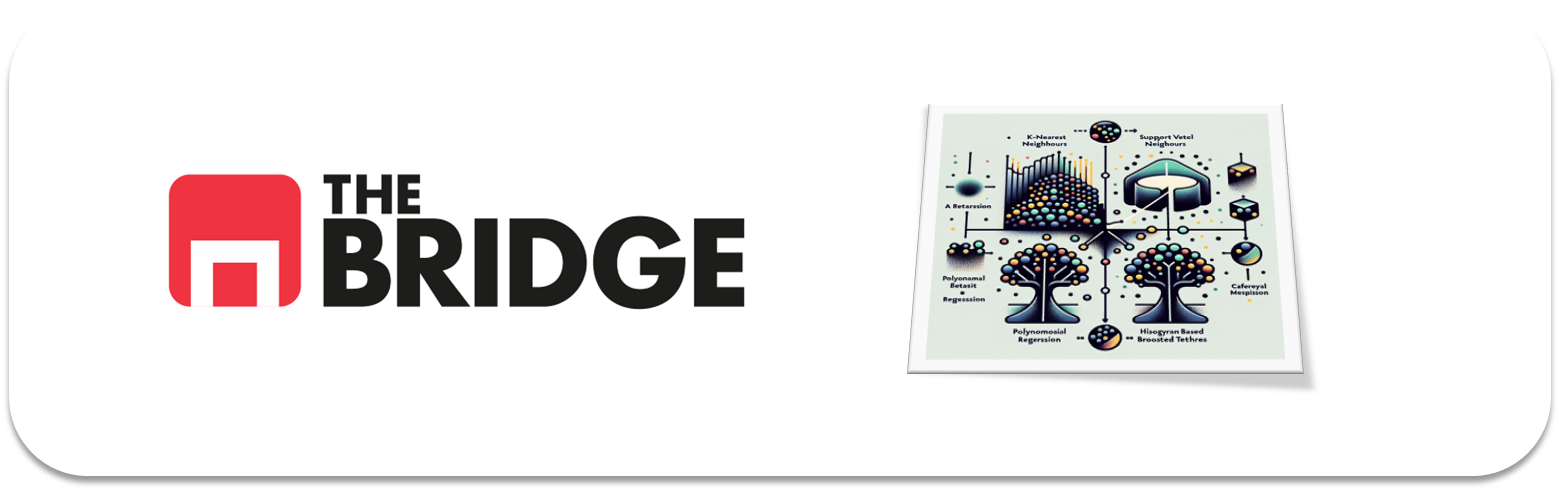

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt    # He tenido que instalar cosas, tenía antiguo el requirements o está incompleto
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import resample

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


**Descripción de variables** (con ayuda de Kaggle/UCI):

| Variable | Descripción |
|---|---|
| SeriousDlqin2yrs | **TARGET**: morosidad grave (+90 días) en los 2 años siguientes. 1=sí, 0=no |
| RevolvingUtilizationOfUnsecuredLines | % de crédito sin garantía usado (tarjetas). Alto = mal asunto |
| age | Edad del prestatario en años |
| NumberOfTime30-59DaysPastDueNotWorse | Veces con retraso de 30-59 días en los últimos 2 años |
| DebtRatio | Ratio deuda/ingresos. Alto = presión financiera |
| MonthlyIncome | Ingreso mensual. Tiene missings, habrá que imputar |
| NumberOfOpenCreditLinesAndLoans | Líneas de crédito y préstamos activos |
| NumberOfTimes90DaysLate | Veces con retraso grave (+90 días) |
| NumberRealEstateLoansOrLines | Préstamos hipotecarios o con garantía inmobiliaria |
| NumberOfTime60-89DaysPastDueNotWorse | Veces con retraso de 60-89 días en los últimos 2 años |
| NumberOfDependents | Personas a cargo (sin contarse a sí mismo). También tiene missings |

**Clasificación inicial:**
- **Numéricas continuas**: RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, MonthlyIncome
- **Numéricas discretas** (tratables como categóricas): el resto de `NumberOf...`

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Es un problema de **clasificación binaria**: predecir si un prestatario tendrá dificultades financieras graves en los dos próximos años.

La variable **target** es `SeriousDlqin2yrs` (1 = problemas, 0 = sin problemas).

### #1.3
Pinta la distribución de frecuencias del target y coméntala

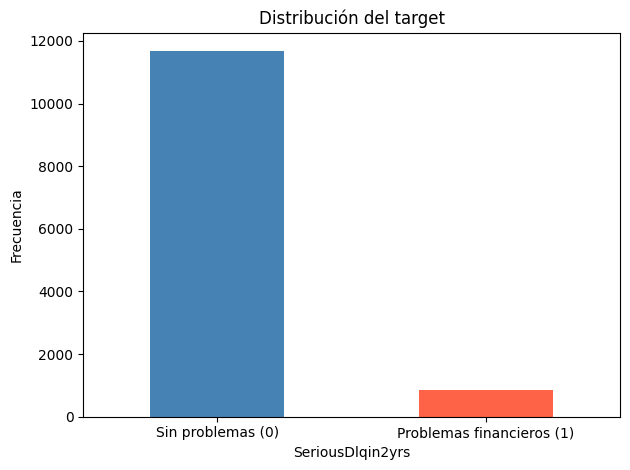

SeriousDlqin2yrs
0    0.931
1    0.069
Name: proportion, dtype: float64


In [5]:
target = "SeriousDlqin2yrs"

df[target].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Distribución del target")
plt.xticks([0,1], ["Sin problemas (0)", "Problemas financieros (1)"], rotation=0)
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(df[target].value_counts(normalize=True).round(3))

In [6]:
#muy desbalanceado

El target está muy **desbalanceado**: la clase 0 (sin problemas) representa ~93% de los casos 
frente al ~7% de la clase 1. Esto obligará a aplicar técnicas de balanceo antes del modelado 
(oversampling, undersampling o ajuste por hiperparámetros).

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [7]:
# poco que limpiar – los missings los imputamos después del split, como manda el manual

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])

In [8]:
# variables auxiliares para no escribir el nombre completo cada vez que las necesite

ndp = "NumberOfDependents"
mi = "MonthlyIncome"

In [9]:
moda_ndp = train_set[ndp].mode()[0]  ## NumberOfDependents es discreta - la moda

train_set[ndp] = train_set[ndp].fillna(moda_ndp)
test_set[ndp] = test_set[ndp].fillna(moda_ndp)

In [10]:
# MonthlyIncome tiene extremos – mediana

mediana_mi = train_set[mi].quantile(0.5)

train_set[mi] = train_set[mi].fillna(mediana_mi)
test_set[mi] = test_set[mi].fillna(mediana_mi)

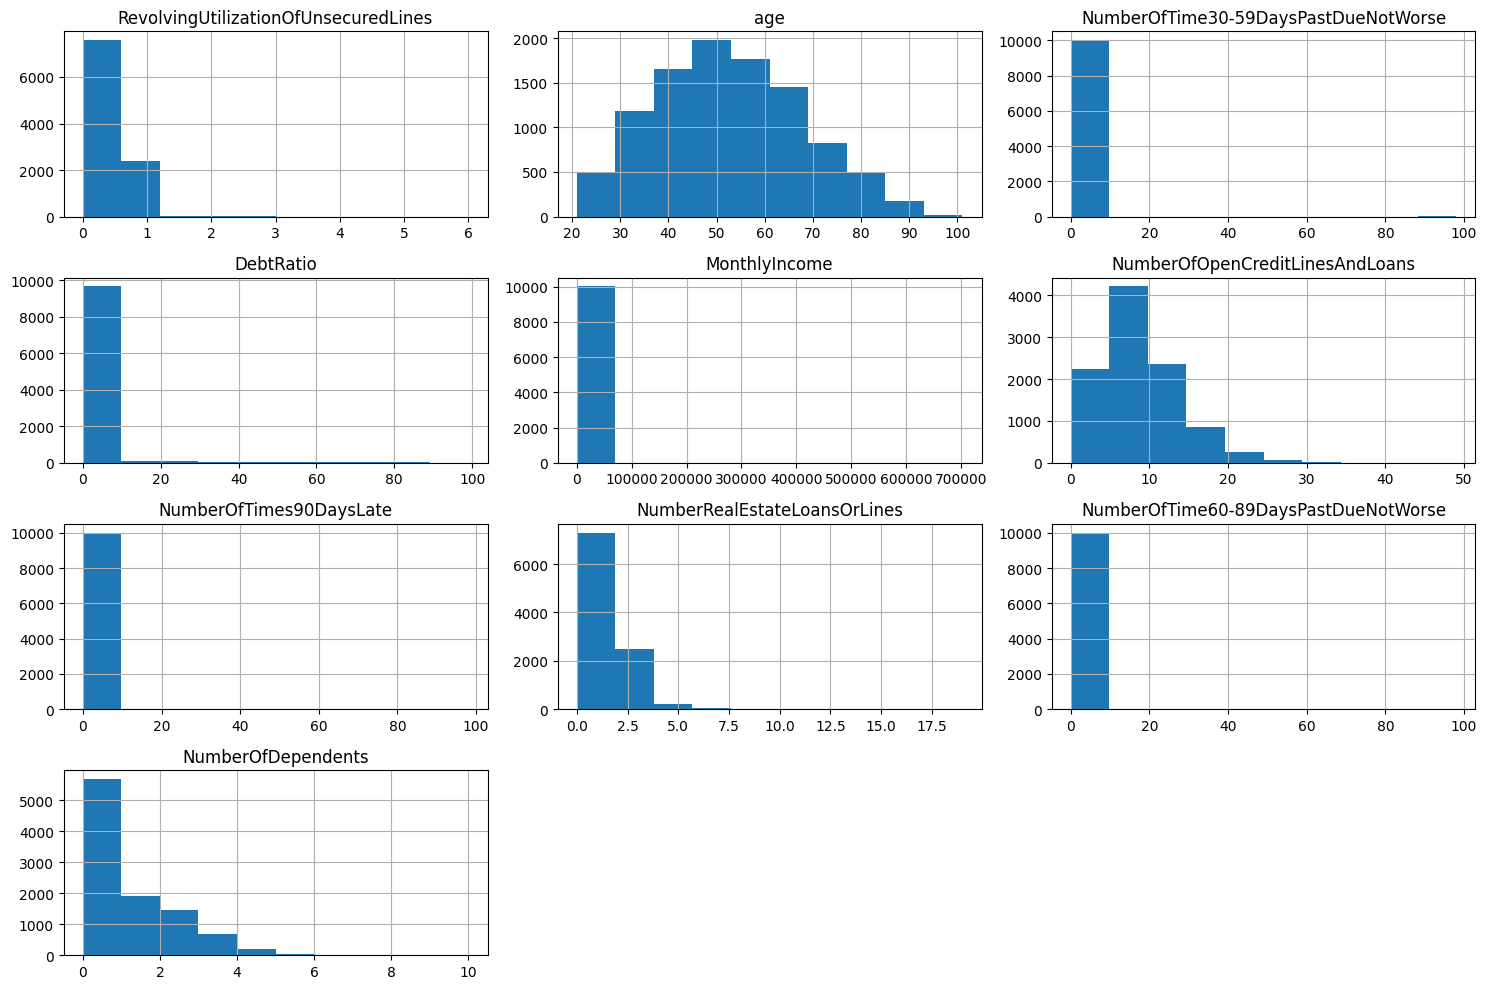

In [11]:
# miniEDA

features = [col for col in train_set.columns if col != target]

train_set[features].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [12]:
numberOf = [col for col in train_set if col.startswith("NumberOfTime")]
for col in numberOf:
    print(f"Pagadores – {col}:")
    print(train_set[train_set[target] == 0][col].value_counts(normalize=True).head(3).round(3))
    print(f"Impagadores:")
    print(train_set[train_set[target] == 1][col].value_counts(normalize=True).head(3).round(3))
    print("---")

Pagadores – NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
0    0.860
1    0.100
2    0.025
Name: proportion, dtype: float64
Impagadores:
NumberOfTime30-59DaysPastDueNotWorse
0    0.530
1    0.229
2    0.130
Name: proportion, dtype: float64
---
Pagadores – NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
0    0.966
1    0.025
2    0.005
Name: proportion, dtype: float64
Impagadores:
NumberOfTimes90DaysLate
0    0.663
1    0.148
2    0.088
Name: proportion, dtype: float64
---
Pagadores – NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
0    0.963
1    0.030
2    0.004
Name: proportion, dtype: float64
Impagadores:
NumberOfTime60-89DaysPastDueNotWorse
0    0.755
1    0.164
2    0.051
Name: proportion, dtype: float64
---


Las variables *NumberOfTime* son las más discriminativas: los pagadores tienen casi siempre  
valor 0, mientras que los impagadores muestran más variedad. `age` también parece aportar. 
El resto de variables tienen distribuciones muy similares entre clases, aunque las incluimos 
todas por ser pocas features.
```recordatorio de cambiar los tipos de celda
```

In [13]:
# Generamos copias escaladas

train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

In [14]:
# log(x+1) a todas menos age – todas tienen ceros así que no podemos log directo

for col in features:
    if col != "age":
        train_set_scaled[col] = np.log(train_set_scaled[col] + 1)
        test_set_scaled[col] = np.log(test_set_scaled[col] + 1)

In [15]:
# escalado estándar – fit solo en train, transform en ambos

scaler = StandardScaler()

train_set_scaled[features] = scaler.fit_transform(train_set_scaled[features])
test_set_scaled[features] = scaler.transform(test_set_scaled[features])

In [16]:
# generamos todos los juegos de X,y que necesitaremos

X_train = train_set[features]
X_train_scaled = train_set_scaled[features]
y_train = train_set[target]

X_test = test_set[features]
X_test_scaled = test_set_scaled[features]
y_test = test_set[target]

In [17]:
# KNN es sensible a las escalas – generamos versión escalada del train y test
# aplicamos log(x+1) primero porque hay ceros y outliers bestiales

train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

for col in features:
    if col != "age":
        train_set_scaled[col] = np.log(train_set_scaled[col] + 1)
        test_set_scaled[col] = np.log(test_set_scaled[col] + 1)

In [18]:
# ahora estandarizamos – fit solo sobre train, transform sobre ambos

scaler = StandardScaler()

train_set_scaled[features] = scaler.fit_transform(train_set_scaled[features])
test_set_scaled[features] = scaler.transform(test_set_scaled[features])

In [19]:
# generamos todos los juegos de X,y que necesitaremos

X_train = train_set[features]
X_train_scaled = train_set_scaled[features]
y_train = train_set[target]

X_test = test_set[features]
X_test_scaled = test_set_scaled[features]
y_test = test_set[target]

In [20]:
# baseline con KNN – k=7 arbitrario, siempre impar

knn_clf = KNeighborsClassifier(n_neighbors=7)
knn_clf.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
# evaluamos contra train para tener un punto de partida – no es el resultado final

print(classification_report(y_train, knn_clf.predict(X_train_scaled)))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9338
           1       0.69      0.23      0.34       691

    accuracy                           0.94     10029
   macro avg       0.82      0.61      0.66     10029
weighted avg       0.93      0.94      0.93     10029



Baseline malo como era de esperar con el dataset desbalanceado – el modelo ignora casi por 
completo la clase 1. Queda claro que hay que aplicar técnicas de balanceo.

In [22]:
# comparativa de 5 modelos con validación cruzada antes de tocar nada
# KNN y Logistic necesitan datos escalados, los basados en árboles no

modelos = ["KNN", "Logistic", "RandomF", "XGBoost", "LightGBM"]

lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose=-1, n_jobs=-1)

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end=" ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring="balanced_accuracy"))
    print(metrica)

Para KNN: 0.5738809143505257
Para Logistic: 0.5621148954635444
Para RandomF: 0.5530236484401414
Para XGBoost: 0.5981654200139266
Para LightGBM: 0.5940385606477767


In [23]:
# SMOTE – generamos datos sintéticos de la clase minoritaria

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_smote_scaled, y_train_smote_scaled = smote.fit_resample(X_train_scaled, y_train)

In [24]:
# comprobamos que ahora las clases están equilibradas

print("Original:", y_train.value_counts().to_dict())
print("SMOTE:", y_train_smote.value_counts().to_dict())

Original: {0: 9338, 1: 691}
SMOTE: {0: 9338, 1: 9338}


In [25]:
# bajamos la clase mayoritaria al nivel de la minoritaria

clase_mayoritaria = X_train[y_train == 0]
clase_minoritaria = X_train[y_train == 1]
clase_mayoritaria_scaled = X_train_scaled[y_train == 0]
clase_minoritaria_scaled = X_train_scaled[y_train == 1]

clase_may_bajo = resample(clase_mayoritaria, replace=False,
                          n_samples=len(clase_minoritaria), random_state=42)

X_train_under = pd.concat([clase_may_bajo, clase_minoritaria])
y_train_under = pd.concat([y_train.loc[clase_may_bajo.index],
                            y_train.loc[clase_minoritaria.index]])

clase_may_bajo_scl = resample(clase_mayoritaria_scaled, replace=False,
                               n_samples=len(clase_minoritaria_scaled), random_state=42)

X_train_under_scl = pd.concat([clase_may_bajo_scl, clase_minoritaria_scaled])
y_train_under_scl = pd.concat([y_train.loc[clase_may_bajo_scl.index],
                                y_train.loc[clase_minoritaria_scaled.index]])

In [26]:
# comparativa con SMOTE – ¿mejora el balanceo artificial?

modelos = ["KNN", "Logistic", "RandomF", "XGBoost", "LightGBM"]

lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, verbose=-1, random_state=42, n_jobs=-1)

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end=" ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train_smote, y_train_smote, cv=5, scoring="balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_smote_scaled, y_train_smote_scaled, cv=5, scoring="balanced_accuracy"))
    print(metrica)

Para KNN: 0.8956423065321388
Para Logistic: 0.7820205611035349
Para RandomF: 0.8167178677561019
Para XGBoost: 0.9148152173040376
Para LightGBM: 0.8997160762436502


In [27]:
# comparativa con undersampling

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end=" ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train_under, y_train_under, cv=5, scoring="balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_under_scl, y_train_under_scl, cv=5, scoring="balanced_accuracy"))
    print(metrica)

Para KNN: 0.756162026900219
Para Logistic: 0.7720779897820874
Para RandomF: 0.7655979564174747
Para XGBoost: 0.7366541549369201
Para LightGBM: 0.7482327181732875


In [28]:
# sin tocar datos pero con class_weight – dejamos que el modelo compense el desbalanceo solo

knn_clf = KNeighborsClassifier(n_neighbors=7, weights="distance")
lr_clf = LogisticRegression(max_iter=10000, class_weight="balanced")
rf_clf = RandomForestClassifier(max_depth=5, random_state=42, class_weight="balanced")
xgb_clf = XGBClassifier(max_depth=5, random_state=42,
                         scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))
lgb_clf = LGBMClassifier(max_depth=5, verbose=-1, random_state=42, class_weight="balanced", n_jobs=-1)

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end=" ")
    if nombre not in modelos[0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring="balanced_accuracy"))
    print(metrica)

Para KNN: 0.5747895872395858
Para Logistic: 0.7722222977677402
Para RandomF: 0.764310223682256
Para XGBoost: 0.6756988549419741
Para LightGBM: 0.7441822823703934


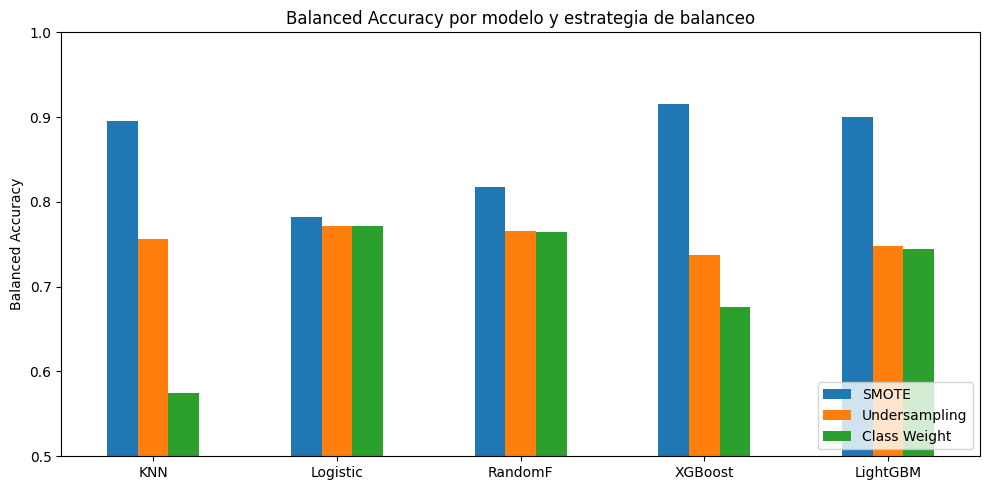

In [29]:
resultados = {
    "SMOTE": [0.896, 0.782, 0.817, 0.915, 0.900],
    "Undersampling": [0.756, 0.772, 0.766, 0.737, 0.748],
    "Class Weight": [0.575, 0.772, 0.764, 0.676, 0.744]
}

modelos_nombres = ["KNN", "Logistic", "RandomF", "XGBoost", "LightGBM"]

df_resultados = pd.DataFrame(resultados, index=modelos_nombres)

df_resultados.plot(kind="bar", figsize=(10, 5), ylim=(0.5, 1.0))
plt.title("Balanced Accuracy por modelo y estrategia de balanceo")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Comparando las tres estrategias de balanceo, SMOTE es la clara ganadora. 
XGBoost obtiene el mejor balanced_accuracy (0.91), seguido de cerca por LightGBM (0.90) y KNN (0.89). 
Undersampling y class_weight se quedan muy por detrás, probablemente por la pérdida de información 
en el primero y la dificultad de compensar un desbalanceo tan extremo (~93/7) solo con pesos.
Nos quedamos con **XGBoost entrenado sobre el dataset SMOTE** para ajustar hiperparámetros.

In [30]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.1, 0.5],
    "max_depth": [5, 10],
    "scale_pos_weight": [1]  # ya está balanceado con SMOTE
}

xgb_clf = XGBClassifier(random_state=42)

xgb_grid = GridSearchCV(xgb_clf,
                         param_grid=param_grid,
                         cv=5,
                         scoring="balanced_accuracy",
                         n_jobs=-1)

xgb_grid.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.5], 'max_depth': [5, 10], 'n_estimators': [100, 200], 'scale_pos_weight': [1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [31]:
print("Mejores hiperparámetros:", xgb_grid.best_params_)
print("Mejor score CV:", round(xgb_grid.best_score_, 4))

Mejores hiperparámetros: {'learning_rate': 0.5, 'max_depth': 10, 'n_estimators': 200, 'scale_pos_weight': 1}
Mejor score CV: 0.9372


In [32]:
# evaluación contra test

print(classification_report(y_test, xgb_grid.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2335
           1       0.32      0.33      0.33       173

    accuracy                           0.91      2508
   macro avg       0.64      0.64      0.64      2508
weighted avg       0.91      0.91      0.91      2508



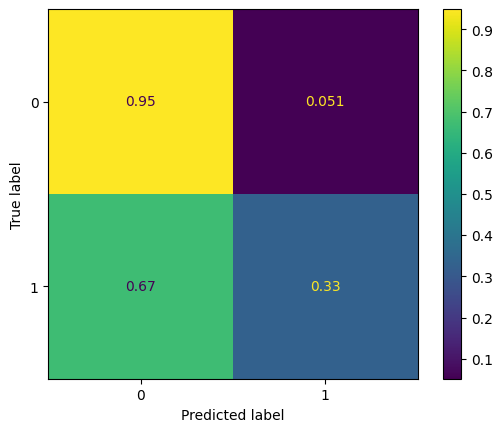

In [34]:
# matriz de confusión normalizada – 
ConfusionMatrixDisplay.from_predictions(y_test, xgb_grid.best_estimator_.predict(X_test), normalize="true")
plt.show()

In [35]:
# análisis de errores – probabilidades de la clase 1 para ver dónde falla el modelo

y_proba = xgb_grid.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = xgb_grid.best_estimator_.predict(X_test)

error_set = test_set.copy()
error_set["proba"] = y_proba
error_set["pred"] = y_pred

bien_clasificadas = error_set[target] == error_set["pred"]
mal_clasificadas = ~bien_clasificadas
clase_1 = error_set[target] == 1

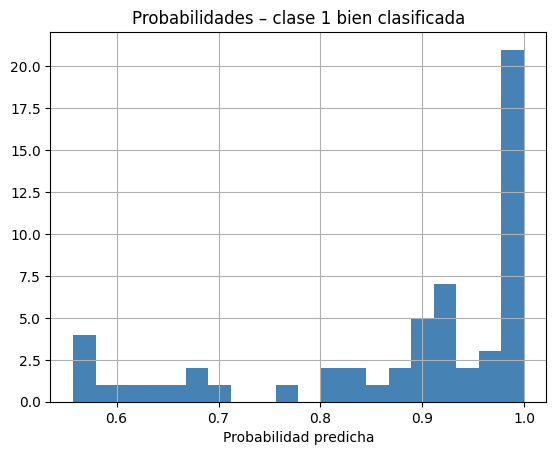

In [36]:
# cuando acierta en clase 1, ¿con qué confianza lo hace?
error_set[bien_clasificadas & clase_1]["proba"].hist(bins=20, color="steelblue")
plt.title("Probabilidades – clase 1 bien clasificada")
plt.xlabel("Probabilidad predicha")
plt.show()

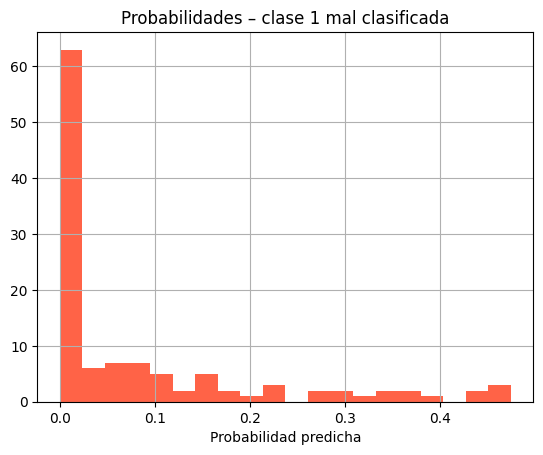

In [37]:
# cuando falla en clase 1, ¿cómo de perdido estaba?
error_set[mal_clasificadas & clase_1]["proba"].hist(bins=20, color="tomato")
plt.title("Probabilidades – clase 1 mal clasificada")
plt.xlabel("Probabilidad predicha")
plt.show()

El modelo tiene buen recall en clase 0 (95%) pero flojo en clase 1 (33%) – predecir impagadores 
es difícil con tan pocos ejemplos reales. Cuando falla en clase 1 lo hace con probabilidades bajas, 
señal de que el modelo duda. Posibles mejoras: ajustar el threshold por debajo de 0.5, 
añadir más features o revisar si hay subgrupos que el modelo no está viendo bien.